# BVA Qudit Analysis

This notebook reads BVA summary logs from `Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs` in read-only mode.
It filters by qudit `dimension`, `LT_comp`, and `date_time`, then reproduces the same style of analysis as the existing BVA notebook.


In [6]:
from pathlib import Path
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

LOG_ROOT = Path(r"Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs")

# User inputs.
dimension = 13
LT_comp = False
date_time = "20260410_1618"

print(f"Using read-only log directory: {LOG_ROOT}")
print(f"dimension = {dimension}")
print(f"LT_comp = {LT_comp}")
print(f"date_time = {date_time}")


def parse_population_line(line):
    line = line.strip()
    if line.startswith('[') and line.endswith(']'):
        line = line[1:-1]
    values = np.fromstring(line, sep=' ')
    return values


def parse_hidden_value(hidden_token):
    token = str(hidden_token).strip()
    if token == "":
        raise ValueError("hidden token is empty")
    try:
        return int(token)
    except ValueError as exc:
        raise ValueError(f"Could not parse hidden value '{token}' as an integer") from exc


def parse_log_filename(path):
    base = Path(path).name
    dim_match = re.search(r"BVA_(\d+)_", base, flags=re.IGNORECASE)
    hidden_match = re.search(r"hiddenval_([^_]+)", base, flags=re.IGNORECASE)
    lt_match = re.search(r"LT_comp_(True|False)", base, flags=re.IGNORECASE)
    dt_matches = re.findall(r"(\d{8}_\d{4,6})", base)

    if dim_match is None or hidden_match is None or not dt_matches:
        return None

    hidden_token = hidden_match.group(1)
    try:
        hidden_value = parse_hidden_value(hidden_token)
    except ValueError:
        return None

    return {
        "filename": base,
        "dimension": int(dim_match.group(1)),
        "hidden_token": hidden_token,
        "hidden_value": hidden_value,
        "lt_comp": None if lt_match is None else (lt_match.group(1) == "True"),
        "date_time": dt_matches[-1],
    }


def load_qudit_bva_logs(log_root, dimension, LT_comp, date_time):
    log_root = Path(log_root)
    if not log_root.exists():
        raise FileNotFoundError(f"Log directory does not exist or is not accessible: {log_root}")

    matched_meta = []
    for path in sorted(log_root.glob("*")):
        if not path.is_file():
            continue
        meta = parse_log_filename(path)
        if meta is None:
            continue
        if meta["dimension"] != int(dimension):
            continue
        if meta["lt_comp"] is None or meta["lt_comp"] != bool(LT_comp):
            continue
        if str(date_time) not in meta["date_time"]:
            continue
        meta["path"] = str(path)
        matched_meta.append(meta)

    if not matched_meta:
        raise FileNotFoundError(
            "No matching BVA log files were found for the requested dimension / LT_comp / date_time filter."
        )

    pop_data = {}
    file_paths = {}
    summary_paths = {}

    for meta in matched_meta:
        path = Path(meta["path"])
        lines = path.read_text(encoding='utf-8').splitlines()
        if len(lines) < 2:
            print(f"Skipping {path.name}: file does not contain enough lines.")
            continue

        pop_vector = parse_population_line(lines[0])
        experiment_path = lines[-1].strip()
        hidden_value = meta["hidden_value"]

        pop_data[hidden_value] = pop_vector
        file_paths[hidden_value] = experiment_path
        summary_paths[hidden_value] = str(path)

    hidden_values = sorted(pop_data.keys())
    if not hidden_values:
        raise ValueError("Matching files were found, but none contained usable population data.")

    return hidden_values, pop_data, file_paths, summary_paths


hidden_values, pop_data, file_paths, summary_paths = load_qudit_bva_logs(
    LOG_ROOT,
    dimension=dimension,
    LT_comp=LT_comp,
    date_time=date_time,
)

print(f"Matched hidden values: {hidden_values}")
print(f"Matched file count: {len(hidden_values)}")
missing_hidden_values = [value for value in range(dimension) if value not in hidden_values]
print(f"Missing hidden values: {missing_hidden_values}")


Using read-only log directory: Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs
dimension = 13
LT_comp = False
date_time = 20260410_1618
Matched hidden values: [0, 1, 2, 3, 4]
Matched file count: 5
Missing hidden values: [5, 6, 7, 8, 9, 10, 11, 12]


11.5
(183, 14)
200
[0.         0.45901639 0.16393443 0.04918033 0.03825137 0.08196721
 0.06010929 0.01092896 0.03278689 0.0273224  0.03278689 0.03825137
 0.00546448 0.        ]
10.5
(177, 14)
200
[0.         0.20338983 0.06779661 0.00564972 0.09039548 0.01694915
 0.01129944 0.01129944 0.02259887 0.00564972 0.24293785 0.11299435
 0.15254237 0.05649718]
10.5
(178, 14)
200
[0.         0.01685393 0.01685393 0.15730337 0.42134831 0.03370787
 0.01123596 0.01123596 0.         0.03370787 0.03370787 0.14044944
 0.1011236  0.02247191]
9.5
(178, 14)
200
[0.         0.19662921 0.1011236  0.15168539 0.02808989 0.03932584
 0.00561798 0.02808989 0.         0.03932584 0.01123596 0.07865169
 0.15730337 0.16292135]
9.5
(172, 14)
200
[0.         0.09883721 0.03488372 0.33139535 0.0872093  0.11627907
 0.08139535 0.01162791 0.02906977 0.02325581 0.02325581 0.06976744
 0.06395349 0.02906977]


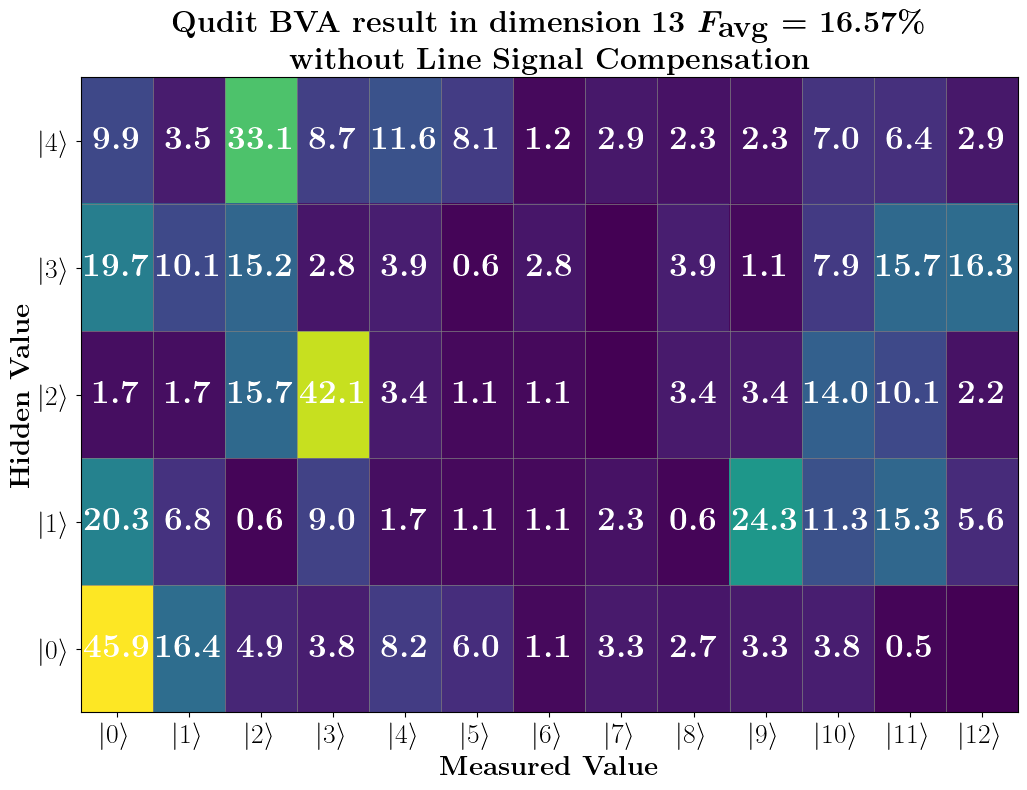

average fidelity = 0.16569706636130452
average detection rate = 0.8880000000000001


In [7]:
def load_experiment_from_file(path):
    exp = []
    with open(path, 'r') as f:
        for line in f:
            exp.append(json.loads(line)[0]["0"])
    return exp


def getShelvingThreshold(counts):
    ds = np.sort(counts, axis=None)
    if len(ds) > 4000:
        ds = ds[2000:]
    if len(ds) > 2000:
        st = round(ds.size / (len(counts) * 0.00150167))
        st = 1 if st < 1 else st
        ds = ds[0:-1:st]
    dsd = ds[1:-1] - ds[0:-2]
    th = max(dsd) / 2 + ds[np.argmax(dsd)]
    hc, be = np.histogram(counts, bins=range(4, 31))
    th = be[np.argmin(hc)] + 0.5
    if th < 2 or th > 20:
        th = 11.5
    return th, ds


keys = hidden_values
n_hidden = len(keys)
ket_avg = [None] * n_hidden
ket_dr = [0.0] * n_hidden
threshold_info = [None] * n_hidden

for row_index, hidden_value in enumerate(keys):
    experiment_path = file_paths[hidden_value]
    experiments = load_experiment_from_file(experiment_path)
    if len(experiments) == 0:
        continue

    experiments = np.asarray(experiments)
    flat_counts = experiments.ravel()
    try:
        threshold, _ = getShelvingThreshold(flat_counts)
        print(threshold)
    except Exception:
        threshold = None

    threshold_info[row_index] = (flat_counts, threshold, hidden_value)
    bright_mask = experiments > threshold
    resolved = np.full(bright_mask.shape, False, dtype=bool)
    for rep_index in range(bright_mask.shape[0]):
        transition_indices = np.where(bright_mask[rep_index])[0]
        # print(transition_indices)
        if transition_indices.size > 0 and transition_indices[0] != 0:
            # print("not empty")
            resolved[rep_index, transition_indices[0]] = True
    # display(resolved)
    valid_rows = resolved.any(axis=1)
    # print(valid_rows)
    filtered = resolved[valid_rows]
    print(filtered.shape)
    ket_dr[row_index] = filtered.shape[0] / experiments.shape[0]
    print(experiments.shape[0])
    if filtered.shape[0] > 0:
        ket_avg[row_index] = np.mean(filtered, axis=0)
        print(ket_avg[row_index])

meas_dim = next((len(vec) - 1 for vec in ket_avg if vec is not None and len(vec) > 1), dimension)
data_m = np.zeros((n_hidden, meas_dim), dtype=float)
for row_index in range(n_hidden):
    if ket_avg[row_index] is not None and len(ket_avg[row_index]) > 1:
        vector = ket_avg[row_index][1:]
        data_m[row_index, :min(len(vector), meas_dim)] = vector[:meas_dim]

fidelities = []
for row_index, hidden_value in enumerate(keys):
    if hidden_value < meas_dim and ket_avg[row_index] is not None:
        fidelities.append(data_m[row_index, hidden_value])

avg_fid = np.mean(fidelities) if fidelities else np.nan
avg_detection_rate = np.mean([value for value in ket_dr if value > 0]) if any(value > 0 for value in ket_dr) else np.nan

fig, ax = plt.subplots(figsize=(max(8, 0.8 * meas_dim), max(8, 0.6 * n_hidden)))
im = ax.imshow(data_m, cmap='viridis', aspect='auto')

hidden_labels = [rf'$|{value}\rangle$' for value in keys]
measured_labels = [rf'$|{value}\rangle$' for value in range(meas_dim)]
ax.set_xticks(np.arange(meas_dim))
ax.set_xticklabels(measured_labels, fontsize=20)
ax.set_yticks(np.arange(n_hidden))
ax.set_yticklabels(hidden_labels, fontsize=20)
ax.invert_yaxis()
ax.set_xlabel(r'\textbf{Measured Value}', fontsize=20)
ax.set_ylabel(r'\textbf{Hidden Value}', fontsize=20)

for row_index in range(n_hidden):
    if ket_avg[row_index] is None:
        ax.text(meas_dim / 2, row_index, r'\textbf{No Valid Data}', ha='center', va='center', color='red', fontsize=14)
    else:
        for col_index in range(meas_dim):
            if data_m[row_index, col_index] > 0.005:
                ax.text(
                    col_index,
                    row_index,
                    rf'\textbf{{{data_m[row_index, col_index] * 100:.1f}}}',
                    ha='center',
                    va='center',
                    color='black' if data_m[row_index, col_index] > 0.5 else 'white',
                    fontsize=24,
                )

for x in np.arange(-0.5, meas_dim, 1):
    ax.axvline(x, color='gray', linewidth=0.5)
for y in np.arange(-0.5, n_hidden, 1):
    ax.axhline(y, color='gray', linewidth=0.5)

line_label = r'\textbf{with Line Signal Compensation}' if LT_comp else r'\textbf{without Line Signal Compensation}'
ax.set_title(
    rf'\textbf{{Qudit BVA result in dimension {dimension} }}' +
    r'\boldmath$F_{\textbf{avg}}$' +
    rf'\textbf{{ = {100.0 * avg_fid:.2f}\%}}' + '\n' + line_label,
    fontsize=22,
)
plt.tight_layout()
plt.show()

print(f"average fidelity = {avg_fid}")
print(f"average detection rate = {avg_detection_rate}")


In [4]:
print(avg_fid)


NameError: name 'avg_fid' is not defined

In [ ]:
# Batch analysis configuration.
# Fill in the dimensions and date_time strings you want to compare.
# The structure is: LT_comp -> {dimension: date_time}
# Long U1 cases:
batch_cases = {
    False: {
        2: "20260330_2008",
        3: "20260330_2017",
        4: "20260330_2017",
        5: "20260330_2102",
        6: "20260330_2131",
        7: "20260330_2208",
        8: "20260331_0954",
        9: "20260331_0954",
        10: "20260331_0954",
        11: "20260331_0954",
        12: "20260331_0954",
        13: "20260401_1032",
        14: "20260401_1739",
        15: "20260401_1838",
    },
    True: {
        15: "20260401_1950",
        14: "20260401_1950",
        13: "20260401_1950",
        12: "20260402_1236",
        11: "20260402_1742",
        10: "20260402_1742",
        9: "20260402_1742",
        8: "20260402_2322",
        3: "20260402_1953",
        4: "20260402_1953",
        5: "20260402_1953",
        6: "20260402_1953",
        7: "20260402_1953",
        2: "20260402_0934",

    },
}

# Short U1 cases:
batch_cases = {
    False: {
        2: "20260403_1258",
        3: "20260403_1258",
        4: "20260403_1258",
        5: "20260403_1258",
        6: "20260403_1258",
        7: "20260403_1258",
        8: "20260403_1403",
        9: "20260403_1403",
        10: "20260403_1653",
        11: "20260403_1728",
        12: "20260403_1754",
        13: "20260403_1839",
        14: "20260403_1839",
        15: "20260403_1839",
        16: "20260406_1019",
    },
    True: {
        # 2: "20260403_1307",
        # 3: "20260403_1307",
        # 4: "20260403_1307",
        # 5: "20260403_1307",
        # 6: "20260403_1307",
        # 7: "20260403_1307",
        # 8: "20260403_1307",
        # 9: "20260403_1307",
        # 10: "20260403_1307",
        16: "20260406_1056",
        15: "20260403_2040",
        14: "20260403_2040",
        13: "20260403_2040",
        12: "20260403_2040",
        11: "20260403_2040",
        10: "20260403_2040",
        9: "20260404_0014",
        8: "20260404_0014",
        7: "20260404_0014",
        6: "20260404_0014",
        5: "20260404_0014",
        4: "20260404_0140",
        3: "20260404_0140",
        2: "20260404_0140",
        },
    }

# Simulation setting for the overlay below.
# Set this to match whether the compared experimental runs used the shortened first state-preparation unitary.
use_short_U1 = True

def analyze_qudit_bva_case(dimension, LT_comp, date_time, log_root=LOG_ROOT):
    hidden_values, pop_data, file_paths, summary_paths = load_qudit_bva_logs(
        log_root,
        dimension=dimension,
        LT_comp=LT_comp,
        date_time=date_time,
    )

    keys = hidden_values
    n_hidden = len(keys)
    ket_avg = [None] * n_hidden
    ket_dr = [0.0] * n_hidden
    valid_shot_counts = [0] * n_hidden

    for row_index, hidden_value in enumerate(keys):
        experiment_path = file_paths[hidden_value]
        experiments = load_experiment_from_file(experiment_path)
        if len(experiments) == 0:
            continue

        experiments = np.asarray(experiments)
        flat_counts = experiments.ravel()
        try:
            threshold, _ = getShelvingThreshold(flat_counts)
        except Exception:
            threshold = None

        bright_mask = experiments > threshold
        resolved = np.full(bright_mask.shape, False, dtype=bool)
        for rep_index in range(bright_mask.shape[0]):
            transition_indices = np.where(bright_mask[rep_index])[0]
            if transition_indices.size > 0 and transition_indices[0] != 0:
                resolved[rep_index, transition_indices[0]] = True

        valid_rows = resolved.any(axis=1)
        filtered = resolved[valid_rows]
        valid_shot_counts[row_index] = int(filtered.shape[0])
        ket_dr[row_index] = filtered.shape[0] / experiments.shape[0]
        if filtered.shape[0] > 0:
            ket_avg[row_index] = np.mean(filtered, axis=0)

    meas_dim = next((len(vec) - 1 for vec in ket_avg if vec is not None and len(vec) > 1), dimension)
    data_m = np.zeros((n_hidden, meas_dim), dtype=float)
    for row_index in range(n_hidden):
        if ket_avg[row_index] is not None and len(ket_avg[row_index]) > 1:
            vector = ket_avg[row_index][1:]
            data_m[row_index, :min(len(vector), meas_dim)] = vector[:meas_dim]

    success_probabilities = []
    binomial_std_per_hidden = []
    valid_hidden_values = []
    valid_counts_for_success = []
    for row_index, hidden_value in enumerate(keys):
        if hidden_value < meas_dim and ket_avg[row_index] is not None:
            p_success = float(data_m[row_index, hidden_value])
            n_valid = int(valid_shot_counts[row_index])
            success_probabilities.append(p_success)
            valid_hidden_values.append(hidden_value)
            valid_counts_for_success.append(n_valid)
            if n_valid > 0:
                binomial_std_per_hidden.append(np.sqrt(p_success * (1.0 - p_success) / n_valid))
            else:
                binomial_std_per_hidden.append(np.nan)

    success_probabilities = np.asarray(success_probabilities, dtype=float)
    binomial_std_per_hidden = np.asarray(binomial_std_per_hidden, dtype=float)
    valid_counts_for_success = np.asarray(valid_counts_for_success, dtype=int)

    avg_success_probability = np.mean(success_probabilities) if success_probabilities.size else np.nan
    hidden_value_std = np.std(success_probabilities, ddof=1) if success_probabilities.size > 1 else 0.0
    binomial_error_of_mean = (
        np.sqrt(np.nansum(binomial_std_per_hidden ** 2)) / success_probabilities.size
        if success_probabilities.size > 0 else np.nan
    )
    total_error_bar = np.sqrt(hidden_value_std ** 2 + binomial_error_of_mean ** 2) if success_probabilities.size > 0 else np.nan

    avg_detection_rate = np.mean([value for value in ket_dr if value > 0]) if any(value > 0 for value in ket_dr) else np.nan
    missing_hidden_values = [value for value in range(dimension) if value not in keys]

    return {
        'dimension': int(dimension),
        'LT_comp': bool(LT_comp),
        'date_time': str(date_time),
        'hidden_values': list(keys),
        'valid_hidden_values': list(valid_hidden_values),
        'missing_hidden_values': missing_hidden_values,
        'data_m': data_m,
        'avg_success_probability': float(avg_success_probability),
        'hidden_value_std': float(hidden_value_std),
        'binomial_error_of_mean': float(binomial_error_of_mean),
        'total_error_bar': float(total_error_bar),
        'avg_detection_rate': float(avg_detection_rate),
        'success_probabilities': success_probabilities,
        'binomial_std_per_hidden': binomial_std_per_hidden,
        'valid_counts_for_success': valid_counts_for_success,
        'summary_paths': dict(summary_paths),
        'experiment_paths': dict(file_paths),
    }


batch_results = {False: [], True: []}
dimensions_by_lt = {False: [], True: []}
avg_success_probability_by_lt = {False: [], True: []}
experimental_error_by_lt = {False: [], True: []}
binomial_error_by_lt = {False: [], True: []}
hidden_std_by_lt = {False: [], True: []}

for lt_value in [False, True]:
    dim_to_datetime = batch_cases.get(lt_value, {})
    for dim_value, dt_value in sorted(dim_to_datetime.items()):
        result = analyze_qudit_bva_case(
            dimension=dim_value,
            LT_comp=lt_value,
            date_time=dt_value,
            log_root=LOG_ROOT,
        )
        batch_results[lt_value].append(result)
        dimensions_by_lt[lt_value].append(int(dim_value))
        avg_success_probability_by_lt[lt_value].append(result['avg_success_probability'])
        experimental_error_by_lt[lt_value].append(result['total_error_bar'])
        binomial_error_by_lt[lt_value].append(result['binomial_error_of_mean'])
        hidden_std_by_lt[lt_value].append(result['hidden_value_std'])

fig, ax = plt.subplots(figsize=(8, 5))
plot_styles = {
    False: {'label': 'AC/LS comp OFF', 'color': '#1f4e79', 'marker': 'o'},
    True: {'label': 'AC/LS comp ON', 'color': '#c05621', 'marker': 's'},
}

for lt_value in [False, True]:
    dims = dimensions_by_lt[lt_value]
    avg_success = avg_success_probability_by_lt[lt_value]
    total_err = experimental_error_by_lt[lt_value]
    if len(dims) == 0:
        continue
    style = plot_styles[lt_value]
    avg_success_pct = 100.0 * np.asarray(avg_success, dtype=float)
    total_err_pct = 100.0 * np.asarray(total_err, dtype=float)
    ax.plot(
        dims,
        avg_success_pct,
        linestyle='-',
        linewidth=2.5,
        marker=style['marker'],
        markersize=8,
        color=style['color'],
        label=style['label'],
    )
    ax.fill_between(
        dims,
        avg_success_pct - total_err_pct,
        avg_success_pct + total_err_pct,
        color=style['color'],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlabel(r'\textbf{Dimension}', fontsize=18)
ax.set_ylabel(r'\textbf{Average Success Probability (\%)}', fontsize=18)
ax.set_title(r'\textbf{Qudit BVA Average Success vs Dimension}', fontsize=20)
ax.grid(True, alpha=0.5)
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

print('dimensions_by_lt =', dimensions_by_lt)
print('avg_success_probability_by_lt =', avg_success_probability_by_lt)
print('experimental_error_by_lt =', experimental_error_by_lt)

for lt_value in [False, True]:
    print(f"\nLT_comp = {lt_value}")
    for result in batch_results[lt_value]:
        print(
            f"  d={result['dimension']:2d}, date_time={result['date_time']}, "
            f"avg_success_probability={100.0 * result['avg_success_probability']:.2f}%, "
            f"total_error_bar={100.0 * result['total_error_bar']:.2f}%, "
            f"binomial_error_of_mean={100.0 * result['binomial_error_of_mean']:.2f}%, "
            f"hidden_value_std={100.0 * result['hidden_value_std']:.2f}%, "
            f"missing_hidden_values={result['missing_hidden_values']}"
        )


KeyboardInterrupt: 

: 

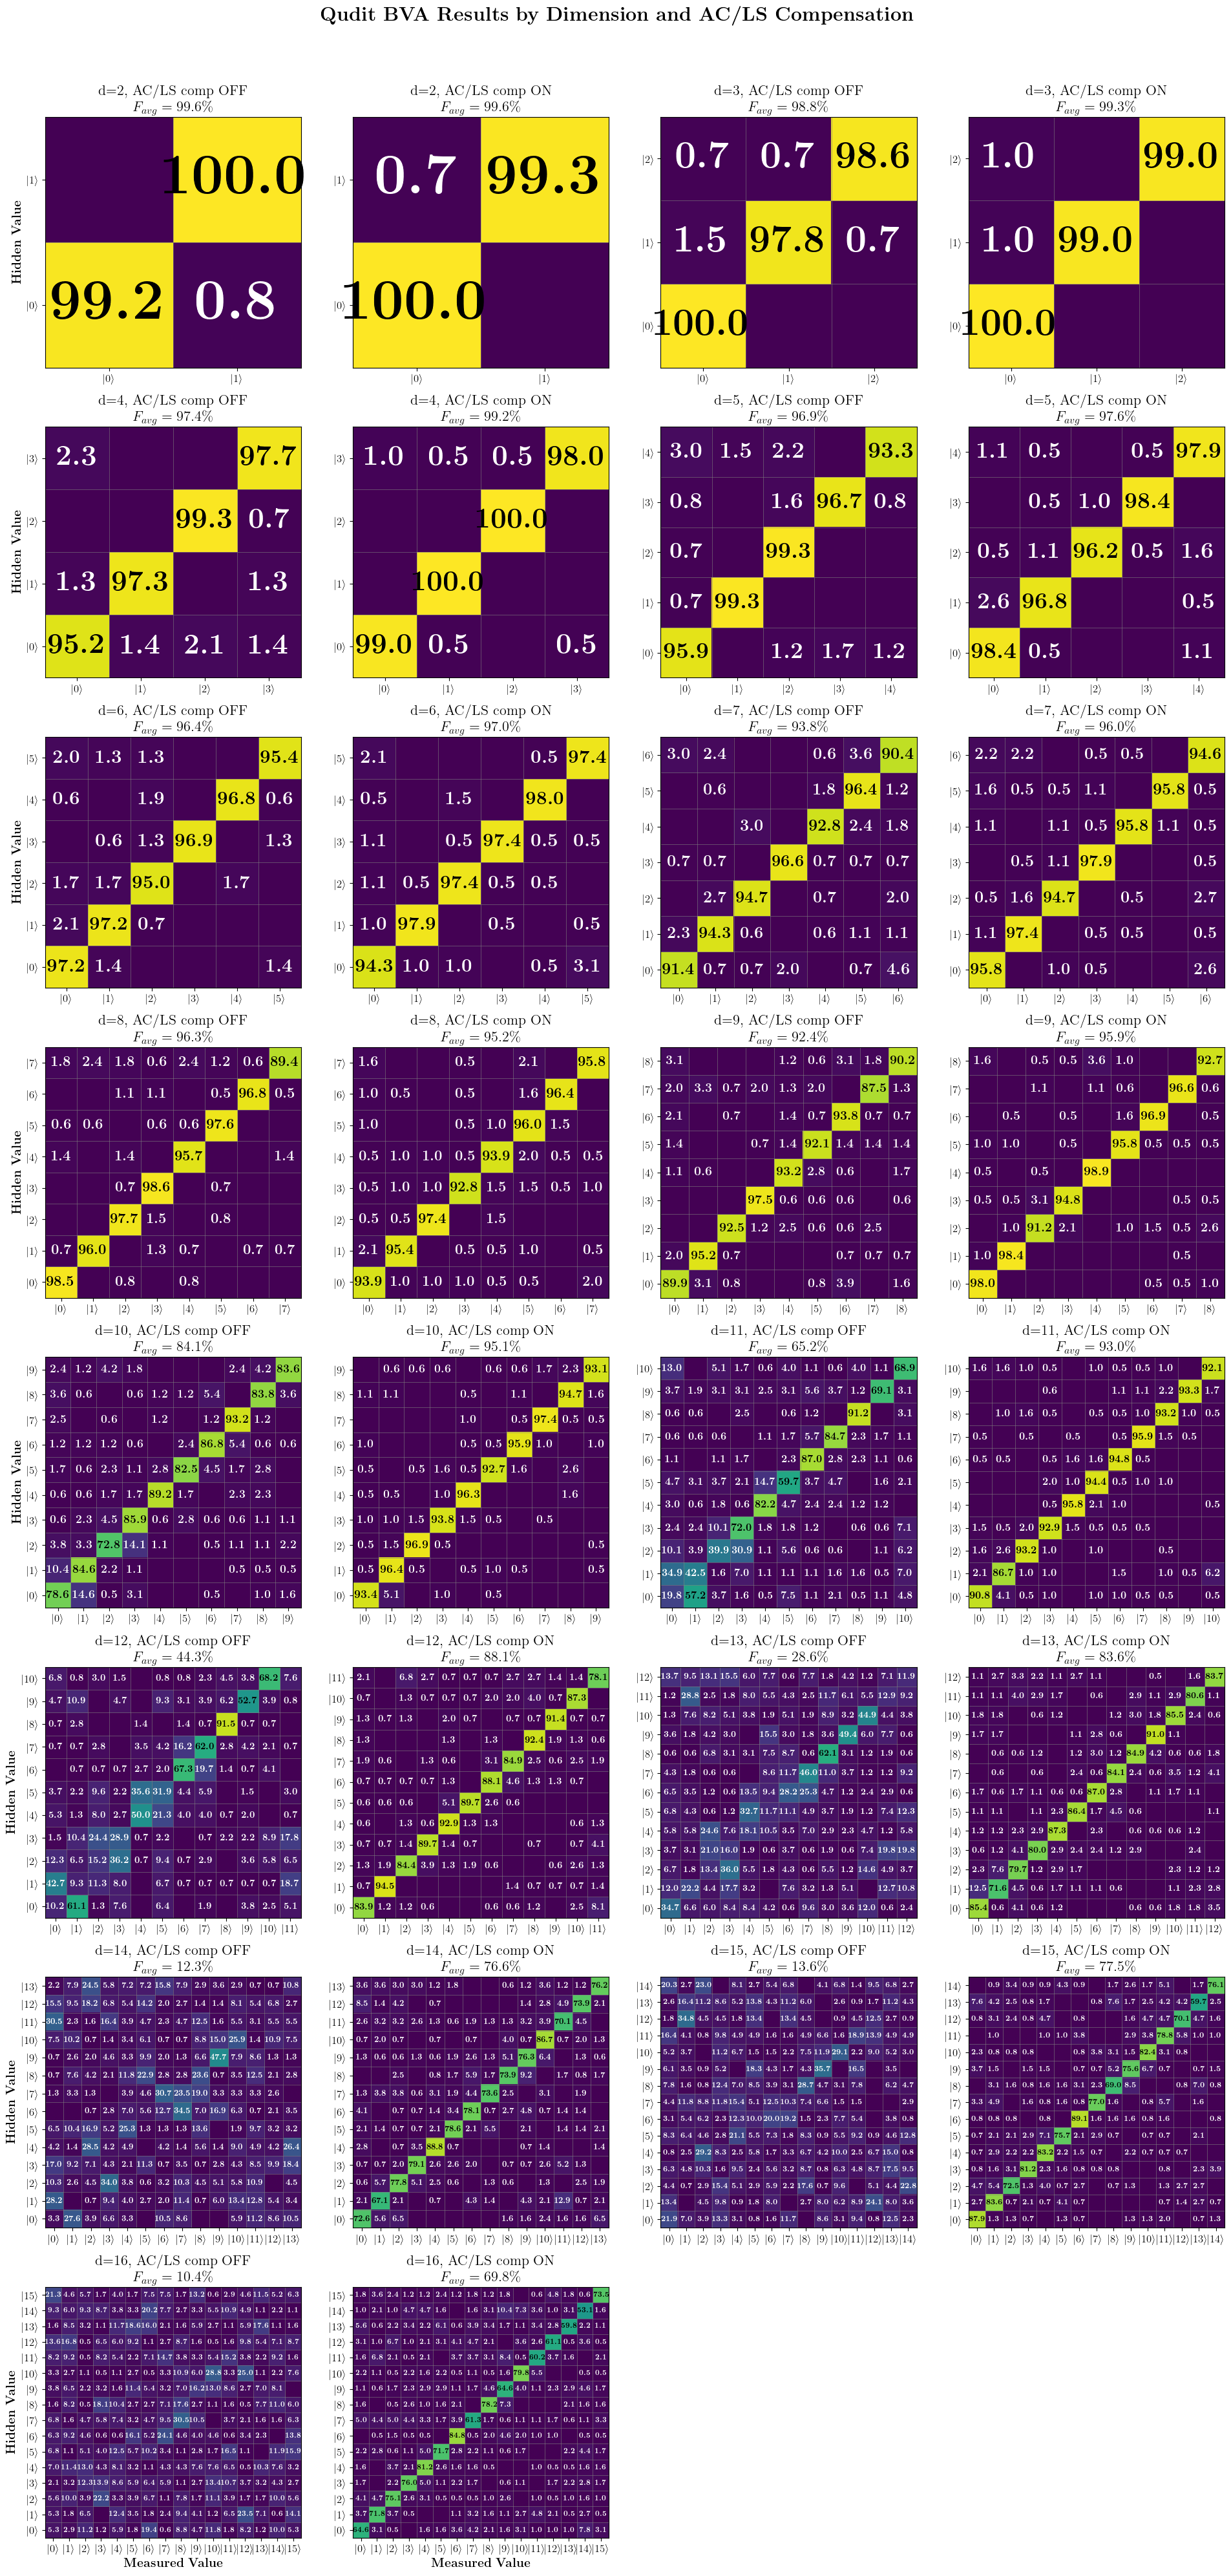

In [97]:
from math import ceil

# Heatmap grid for all analyzed dimensions.
# Layout: 4 columns total, arranged as
# [d1 False, d1 True, d2 False, d2 True] on each row.

result_lookup = {False: {}, True: {}}
for lt_value in [False, True]:
    for result in batch_results[lt_value]:
        result_lookup[lt_value][result['dimension']] = result

all_dimensions = sorted(set(dimensions_by_lt[False]) | set(dimensions_by_lt[True]))
if len(all_dimensions) == 0:
    raise ValueError('No batch analysis results are available to plot.')

pairs_per_row = 2
n_rows = ceil(len(all_dimensions) / pairs_per_row)
n_cols = 4

available_matrices = [
    np.asarray(result_lookup[lt_value][dim_value]['data_m'], dtype=float)
    for dim_value in all_dimensions
    for lt_value in [False, True]
    if dim_value in result_lookup[lt_value]
]
vmax = max(np.max(matrix) for matrix in available_matrices) if available_matrices else 1.0
vmax = max(float(vmax), 1e-6)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, max(4.5, 5.0 * n_rows)),
    squeeze=False,
)

for ax in axes.ravel():
    ax.axis('off')

for dim_index, dim_value in enumerate(all_dimensions):
    row = dim_index // pairs_per_row
    pair_offset = dim_index % pairs_per_row
    base_col = 2 * pair_offset

    for lt_offset, lt_value in enumerate([False, True]):
        ax = axes[row, base_col + lt_offset]
        ax.axis('on')

        result = result_lookup[lt_value].get(dim_value)
        lt_label = 'AC/LS comp ON' if lt_value else 'AC/LS comp OFF'

        if result is None:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f'd={dim_value}, {lt_label}', fontsize=16)
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=18, color='red', transform=ax.transAxes)
            continue

        data_m = np.asarray(result['data_m'], dtype=float)
        im = ax.imshow(data_m, cmap='viridis', aspect='auto', vmin=0.0, vmax=vmax)

        hidden_values = result['hidden_values']
        measured_dim = data_m.shape[1]
        hidden_labels = [rf'$|{value}\rangle$' for value in hidden_values]
        measured_labels = [rf'$|{value}\rangle$' for value in range(measured_dim)]

        ax.set_xticks(np.arange(measured_dim))
        ax.set_xticklabels(measured_labels, fontsize=12)
        ax.set_yticks(np.arange(len(hidden_values)))
        ax.set_yticklabels(hidden_labels, fontsize=12)
        ax.invert_yaxis()
        ax.set_title(
            f'd={dim_value}, {lt_label}\n' + rf'$F_{{avg}} = {100.0 * result["avg_success_probability"]:.1f}\%$',
            fontsize=16,
        )

        if base_col == 0 and lt_offset == 0:
            ax.set_ylabel(r'\textbf{Hidden Value}', fontsize=14)
        else:
            ax.set_ylabel('')

        if row == n_rows - 1:
            ax.set_xlabel(r'\textbf{Measured Value}', fontsize=14)

        for x in np.arange(-0.5, measured_dim, 1):
            ax.axvline(x, color='gray', linewidth=0.4)
        for y in np.arange(-0.5, len(hidden_values), 1):
            ax.axhline(y, color='gray', linewidth=0.4)

        for row_index in range(data_m.shape[0]):
            for col_index in range(data_m.shape[1]):
                value = data_m[row_index, col_index]
                if value <= 0.005:
                    continue
                ax.text(
                    col_index,
                    row_index,
                    rf'\textbf{{{100.0 * value:.1f}}}',
                    ha='center',
                    va='center',
                    color='black' if value > 0.5 else 'white',
                    fontsize=128/dim_value,
                    fontweight='bold',
                )

for row in range(n_rows):
    for col in range(n_cols):
        if not axes[row, col].has_data() and len(axes[row, col].texts) == 0:
            axes[row, col].axis('off')

fig.suptitle(r'\textbf{Qudit BVA Results by Dimension and AC/LS Compensation}', fontsize=22, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [ ]:
import ast
import sys
from pathlib import Path

if 'batch_results' not in globals():
    raise RuntimeError("Run the batch-dimension-analysis cell before running this simulation overlay cell.")

module_dir = Path(r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from Functions_Algorithms import compile_algorithm_pulses

algorithm_simulation_path = module_dir / 'Algorithm_simulation.ipynb'
algorithm_simulation_nb = json.loads(algorithm_simulation_path.read_text(encoding='utf-8'))
algorithm_cell_sources = {
    cell.get('id'): ''.join(cell.get('source', []))
    for cell in algorithm_simulation_nb['cells']
    if cell.get('cell_type') == 'code'
}


def extract_named_assignments(cell_source, keep_names, global_ns):
    tree = ast.parse(cell_source)
    selected_nodes = []
    for node in tree.body:
        if isinstance(node, ast.Assign):
            target_names = [target.id for target in node.targets if isinstance(target, ast.Name)]
            if any(name in keep_names for name in target_names):
                selected_nodes.append(node)
    module = ast.Module(body=selected_nodes, type_ignores=[])
    local_ns = {}
    exec(compile(module, '<selected-assignments>', 'exec'), global_ns, local_ns)
    return local_ns


simulation_ns = {
    'np': np,
    'json': json,
    'plt': plt,
}

user_input_assignments = extract_named_assignments(
    algorithm_cell_sources['user-input'],
    {
        'transition_strengths_file',
        'sensitivity_matrix_file',
        'line_signal_param_file',
        'reference_pi_times_us',
        'reference_strength_indices',
    },
    simulation_ns,
)
simulation_ns.update(user_input_assignments)

for helper_cell_id in ['unitary-helpers', 'decomp-helpers', 'simulation-helpers-1', 'simulation-helpers-2', 'line-signal-file']:
    exec(algorithm_cell_sources[helper_cell_id], simulation_ns, simulation_ns)

helper_src = algorithm_cell_sources['73b13c5c']
if 'pulse_pi_times_list =' in helper_src:
    helper_src = helper_src.split('pulse_pi_times_list =')[0]
exec(helper_src, simulation_ns, simulation_ns)

simulation_input_assignments = extract_named_assignments(
    algorithm_cell_sources['simulation-inputs'],
    {
        'default_pi_time_us',
        'pi_time_by_coupling_us',
        'use_line_noise',
        'line_model',
        'line_reference',
        'num_shots',
        'rng_seed',
        'calibration_scale',
        'magnetic_scale',
        'laser_scale',
        'calibration_noise_hwhm_hz',
        'calibration_noise_sigma_hz',
        'magnetic_field_std_g',
        'laser_gaussian_T_s',
        'laser_lorentzian_L_s',
        'voigt_x_min_hz',
        'voigt_x_max_hz',
        'voigt_num_points',
        'rabi_frequency_std_fraction',
        'line_signal_noise_std_g',
        'apply_final_frame',
    },
    simulation_ns,
)
simulation_ns.update(simulation_input_assignments)
print(simulation_input_assignments)
simulation_mappings = {
    0: '0',
    1: '[4, -2]',
    2: '[3, 1]',
    3: '[4, -1]',
    4: '[3, 0]',
    5: '[3, 2]',
    6: '[4, 0]',
    7: '[2, -2]',
    8: '[2, 0]',
    9: '[2, 2]',
    10: '[4, 1]',
    11: '[3, -1]',
    12: '[1, 1]',
    13: '[2, -1]',
    14: '[1, -1]',
    15: '[2, 1]',
}

center = 0
tol = 1e-10
minimize_gamma = False
initial_frame = None
initial_state_index = 0
simulation_dimensions = list(range(2, 17))


def simulate_bva_average_success(dimensions_to_sweep, use_line_noise_override, use_short_U1_override, seed_offset=0):
    dimensions_sorted = sorted(int(dim_value) for dim_value in dimensions_to_sweep)
    avg_success = []
    std_success = []
    success_by_dimension = {}

    for dim_test in dimensions_sorted:
        if dim_test > len(simulation_mappings):
            raise ValueError(f"dimension {dim_test} exceeds the available simulation mapping size {len(simulation_mappings)}")

        dim_success_probabilities = []
        for hidden_value in range(dim_test):
            pulse_train_list_dim, pulse_angle_list_dim, pulse_phases_list_dim, compile_metadata_dim = compile_algorithm_pulses(
                simulation_mappings,
                dim_test,
                'BVA',
                center=center,
                tol=tol,
                minimize_gamma=minimize_gamma,
                initial_frame=initial_frame,
                return_metadata=True,
                use_short_U1=use_short_U1_override,
                hidden_value=hidden_value,
            )

            final_frame_dim = compile_metadata_dim['final_frame']
            couplings_dim = compile_metadata_dim['couplings']
            unitaries_dim = compile_metadata_dim['unitaries']
            thetas_dim = pulse_angle_list_dim
            phases_dim = pulse_phases_list_dim

            initial_state_dim = simulation_ns['basis_state'](initial_state_index, dim_test)
            target_state_dim = simulation_ns['sequence_target_unitary'](unitaries_dim) @ initial_state_dim

            pulse_pi_times_dim = np.asarray(simulation_ns['get_pi_times'](pulse_train_list_dim), dtype=float)
            pulse_sensitivities_dim = np.asarray(
                simulation_ns['get_values_from_matrix'](pulse_train_list_dim, simulation_ns['sens_matrix']),
                dtype=float,
            )

            base_seed = simulation_ns.get('rng_seed', None)
            if base_seed is None:
                rng_seed_dim = None
            else:
                rng_seed_dim = int(base_seed) + int(seed_offset) + 1000 * dim_test + hidden_value

            simulation_result_dim = simulation_ns['monte_carlo_schedule'](
                couplings=couplings_dim,
                thetas=thetas_dim,
                programmed_phases=phases_dim,
                initial_state=initial_state_dim,
                pulse_sensitivities_mhz_per_g=pulse_sensitivities_dim,
                default_pi_time_us=simulation_ns['default_pi_time_us'],
                pi_time_by_coupling_us=simulation_ns['pi_time_by_coupling_us'],
                per_pulse_pi_time_us=pulse_pi_times_dim,
                final_frame=simulation_ns['wrap_frame'](final_frame_dim),
                apply_final_frame=simulation_ns['apply_final_frame'],
                use_line_noise=use_line_noise_override,
                line_model=simulation_ns['line_model'],
                line_reference=simulation_ns['line_reference'],
                num_shots=simulation_ns['num_shots'],
                rng_seed=rng_seed_dim,
                calibration_scale=simulation_ns['calibration_scale'],
                magnetic_scale=simulation_ns['magnetic_scale'],
                laser_scale=simulation_ns['laser_scale'],
                calibration_noise_hwhm_hz=simulation_ns['calibration_noise_hwhm_hz'],
                calibration_noise_sigma_hz=simulation_ns['calibration_noise_sigma_hz'],
                magnetic_field_std_g=simulation_ns['magnetic_field_std_g'],
                laser_gaussian_T_s=2*np.pi*1997.02e-6,#simulation_ns['laser_gaussian_T_s'],
                laser_lorentzian_L_s=2*np.pi*4215.52e-6,#simulation_ns['laser_lorentzian_L_s'],
                voigt_x_min_hz=simulation_ns['voigt_x_min_hz'],
                voigt_x_max_hz=simulation_ns['voigt_x_max_hz'],
                voigt_num_points=simulation_ns['voigt_num_points'],
                rabi_frequency_std_fraction=simulation_ns['rabi_frequency_std_fraction'],
                line_signal_noise_std_g=simulation_ns['line_signal_noise_std_g'],
                target_state=target_state_dim,
            )

            dim_success_probabilities.append(simulation_result_dim['mean_populations'][hidden_value])

        dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
        success_by_dimension[dim_test] = dim_success_probabilities
        avg_success.append(np.mean(dim_success_probabilities))
        std_success.append(np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0)

    return {
        'dimensions': dimensions_sorted,
        'avg_success_probability': np.asarray(avg_success, dtype=float),
        'std_success_probability': np.asarray(std_success, dtype=float),
        'success_by_dimension': success_by_dimension,
    }


simulation_overlay_results = {
    False: simulate_bva_average_success(
        simulation_dimensions,
        use_line_noise_override=True,
        use_short_U1_override=use_short_U1,
        seed_offset=0,
    ),
    True: simulate_bva_average_success(
        simulation_dimensions,
        use_line_noise_override=False,
        use_short_U1_override=use_short_U1,
        seed_offset=500000,
    ),
}


{'default_pi_time_us': 20.0, 'pi_time_by_coupling_us': {}, 'use_line_noise': True, 'line_model': {'B0_mG': 0.2289, 'A60_mG': -0.2791, 'phi60_rad': 1.0002, 'A180_mG': -0.0774, 'phi180_rad': -0.265, 'param_file': 'Z:\\Lab Data\\Line_signal_fitted_params\\line_signal_fit_params.txt'}, 'line_reference': 'start', 'num_shots': 200, 'rng_seed': 276452903391992234055557191570227570135, 'calibration_scale': 1.0, 'magnetic_scale': 1.0, 'laser_scale': 1.0, 'calibration_noise_hwhm_hz': 15, 'calibration_noise_sigma_hz': 0.0, 'magnetic_field_std_g': 1.113e-05, 'laser_gaussian_T_s': 0.01506095022664491, 'laser_lorentzian_L_s': 0.026486924391589554, 'voigt_x_min_hz': -1000.0, 'voigt_x_max_hz': 1000.0, 'voigt_num_points': 100000, 'rabi_frequency_std_fraction': 0.037, 'line_signal_noise_std_g': 0.0, 'apply_final_frame': False}


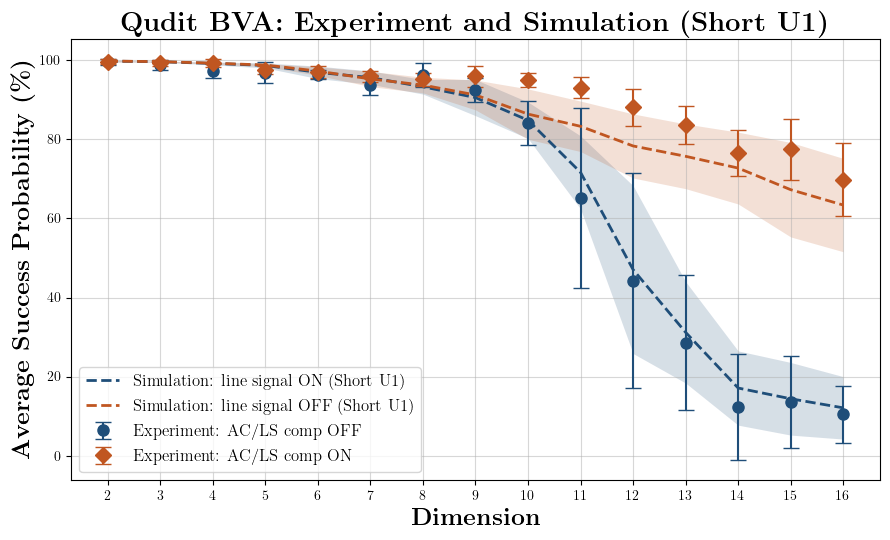

simulation overlay results:

LT_comp=False, simulated with line signal (Short U1)
  d= 2: simulated avg success =  99.81% , std across hidden values =   0.26%
  d= 3: simulated avg success =  99.63% , std across hidden values =   0.10%
  d= 4: simulated avg success =  99.23% , std across hidden values =   0.37%
  d= 5: simulated avg success =  98.70% , std across hidden values =   0.63%
  d= 6: simulated avg success =  96.95% , std across hidden values =   1.58%
  d= 7: simulated avg success =  95.63% , std across hidden values =   1.67%
  d= 8: simulated avg success =  93.31% , std across hidden values =   1.85%
  d= 9: simulated avg success =  90.57% , std across hidden values =   4.57%
  d=10: simulated avg success =  84.85% , std across hidden values =   4.60%
  d=11: simulated avg success =  71.67% , std across hidden values =   9.23%
  d=12: simulated avg success =  47.08% , std across hidden values =  21.23%
  d=13: simulated avg success =  31.21% , std across hidden values =  1

In [101]:
prep_mode_label = 'Short U1' if use_short_U1 else 'Full QFT'


fig, ax = plt.subplots(figsize=(9, 5.5))
plot_styles = {
    False: {
        'color': '#1f4e79',
        'marker': ['o', 'D', '^', 'v', 'P', '*', 'X', 'h', 'H', '8', 'p', '|', '_'],
        'actual_label': 'Experiment: AC/LS comp OFF',
        'sim_label': f'Simulation: line signal ON ({prep_mode_label})',
    },
    True: {
        'color': '#c05621',
        'marker': ['D', '^', 'v', 'P', '*', 'X', 'h', 'H', '8', 'p', '|', '_'],
        'actual_label': 'Experiment: AC/LS comp ON',
        'sim_label': f'Simulation: line signal OFF ({prep_mode_label})',
    },
}
print()
for lt_value in [False, True]:
    style = plot_styles[lt_value]

    dims_exp = dimensions_by_lt[lt_value]
    avg_exp = avg_success_probability_by_lt[lt_value]
    exp_err = experimental_error_by_lt[lt_value]
    if len(dims_exp) > 0:
        avg_exp_pct = 100.0 * np.asarray(avg_exp, dtype=float)
        exp_err_pct = 100.0 * np.asarray(exp_err, dtype=float)
        # ax.plot(
        #     dims_exp,
        #     avg_exp_pct,
        #     plot_styles[lt_value]['marker'][0],
        #     markersize=8,
        #     color=style['color'],
        #     label=style['actual_label'],
        # )

        ax.errorbar(
            dims_exp,
            avg_exp_pct,
            yerr = exp_err_pct,
            linestyle='',
            # linewidth=2.0,
            marker=style['marker'][0],
            markersize=8,
            capsize=6,
            color=style['color'],
            # ecolor=style['color'],
            label=style['actual_label'],
        )

        # ax.fill_between(
        #     dims_exp,
        #     avg_exp_pct - exp_err_pct,
        #     avg_exp_pct + exp_err_pct,
        #     color=style['color'],
        #     alpha=0.18,
        #     linewidth=0,
        # )

    dims_sim = simulation_overlay_results[lt_value]['dimensions']
    avg_sim = simulation_overlay_results[lt_value]['avg_success_probability']
    std_sim = simulation_overlay_results[lt_value]['std_success_probability']
    ax.plot(
        dims_sim,
        100.0 * avg_sim,
        # yerr=100.0 * std_sim,
        linestyle='--',
        linewidth=2.0,
        # marker=style['marker'][2],
        # markersize=6,
        # capsize=4,
        color=style['color'],
        # ecolor=style['color'],
        label=style['sim_label'],
    )

    ax.fill_between(
        dims_sim,
        100.0 * avg_sim - 100.0 * std_sim,
        100.0 * avg_sim + 100.0 * std_sim,
        color=style['color'],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlabel(r'\textbf{Dimension}', fontsize=18)
ax.set_ylabel(r'\textbf{Average Success Probability (\%)}', fontsize=18)
ax.set_title(rf'\textbf{{Qudit BVA: Experiment and Simulation ({prep_mode_label})}}', fontsize=20)
ax.set_xticks(simulation_dimensions)
ax.grid(True, alpha=0.5)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('simulation overlay results:')
for lt_value in [False, True]:
    lt_label = (
        f'LT_comp=False, simulated with line signal ({prep_mode_label})'
        if not lt_value else
        f'LT_comp=True, simulated without line signal ({prep_mode_label})'
    )
    print(f"\n{lt_label}")
    dims_sim = simulation_overlay_results[lt_value]['dimensions']
    avg_sim = simulation_overlay_results[lt_value]['avg_success_probability']
    std_sim = simulation_overlay_results[lt_value]['std_success_probability']
    for dim_test, mean_success, std_success in zip(dims_sim, avg_sim, std_sim):
        print(
            f"  d={dim_test:2d}: simulated avg success = {100.0 * mean_success:6.2f}% , "
            f"std across hidden values = {100.0 * std_success:6.2f}%"
        )
